Pareto

Data successfully loaded and non-dominated Pareto fronts extracted!
1238    101_313_215_312_204
Name: specification, dtype: object
1471    000_200_000_000_000
Name: specification, dtype: object
--- Delphos ---
Closest: seed 4 (dist: 13.1)
  -> Min AIC Model - ID (attempt): 1239, AIC: 7453.47, Params: 34.0
Farthest: seed 0 (dist: 20.6)
  -> Max AIC Model - ID (attempt): 1472, AIC: 9128.42, Params: 1.0

--- SA ---
Closest: seed 6 (dist: 13.4)
  -> Min AIC Model - ID (attempt): 1414, AIC: 7463.02, Params: 29.0
Farthest: seed 5 (dist: 19.7)
  -> Max AIC Model - ID (attempt): 1, AIC: 9409.91, Params: 2.0

--- VNS ---
Closest: seed 4 (dist: 9.0)
  -> Min AIC Model - ID (attempt): 1003, AIC: 7744.16, Params: 22.0
Farthest: seed 6 (dist: 16.7)
  -> Max AIC Model - ID (attempt): 1, AIC: 9409.91, Params: 2.0



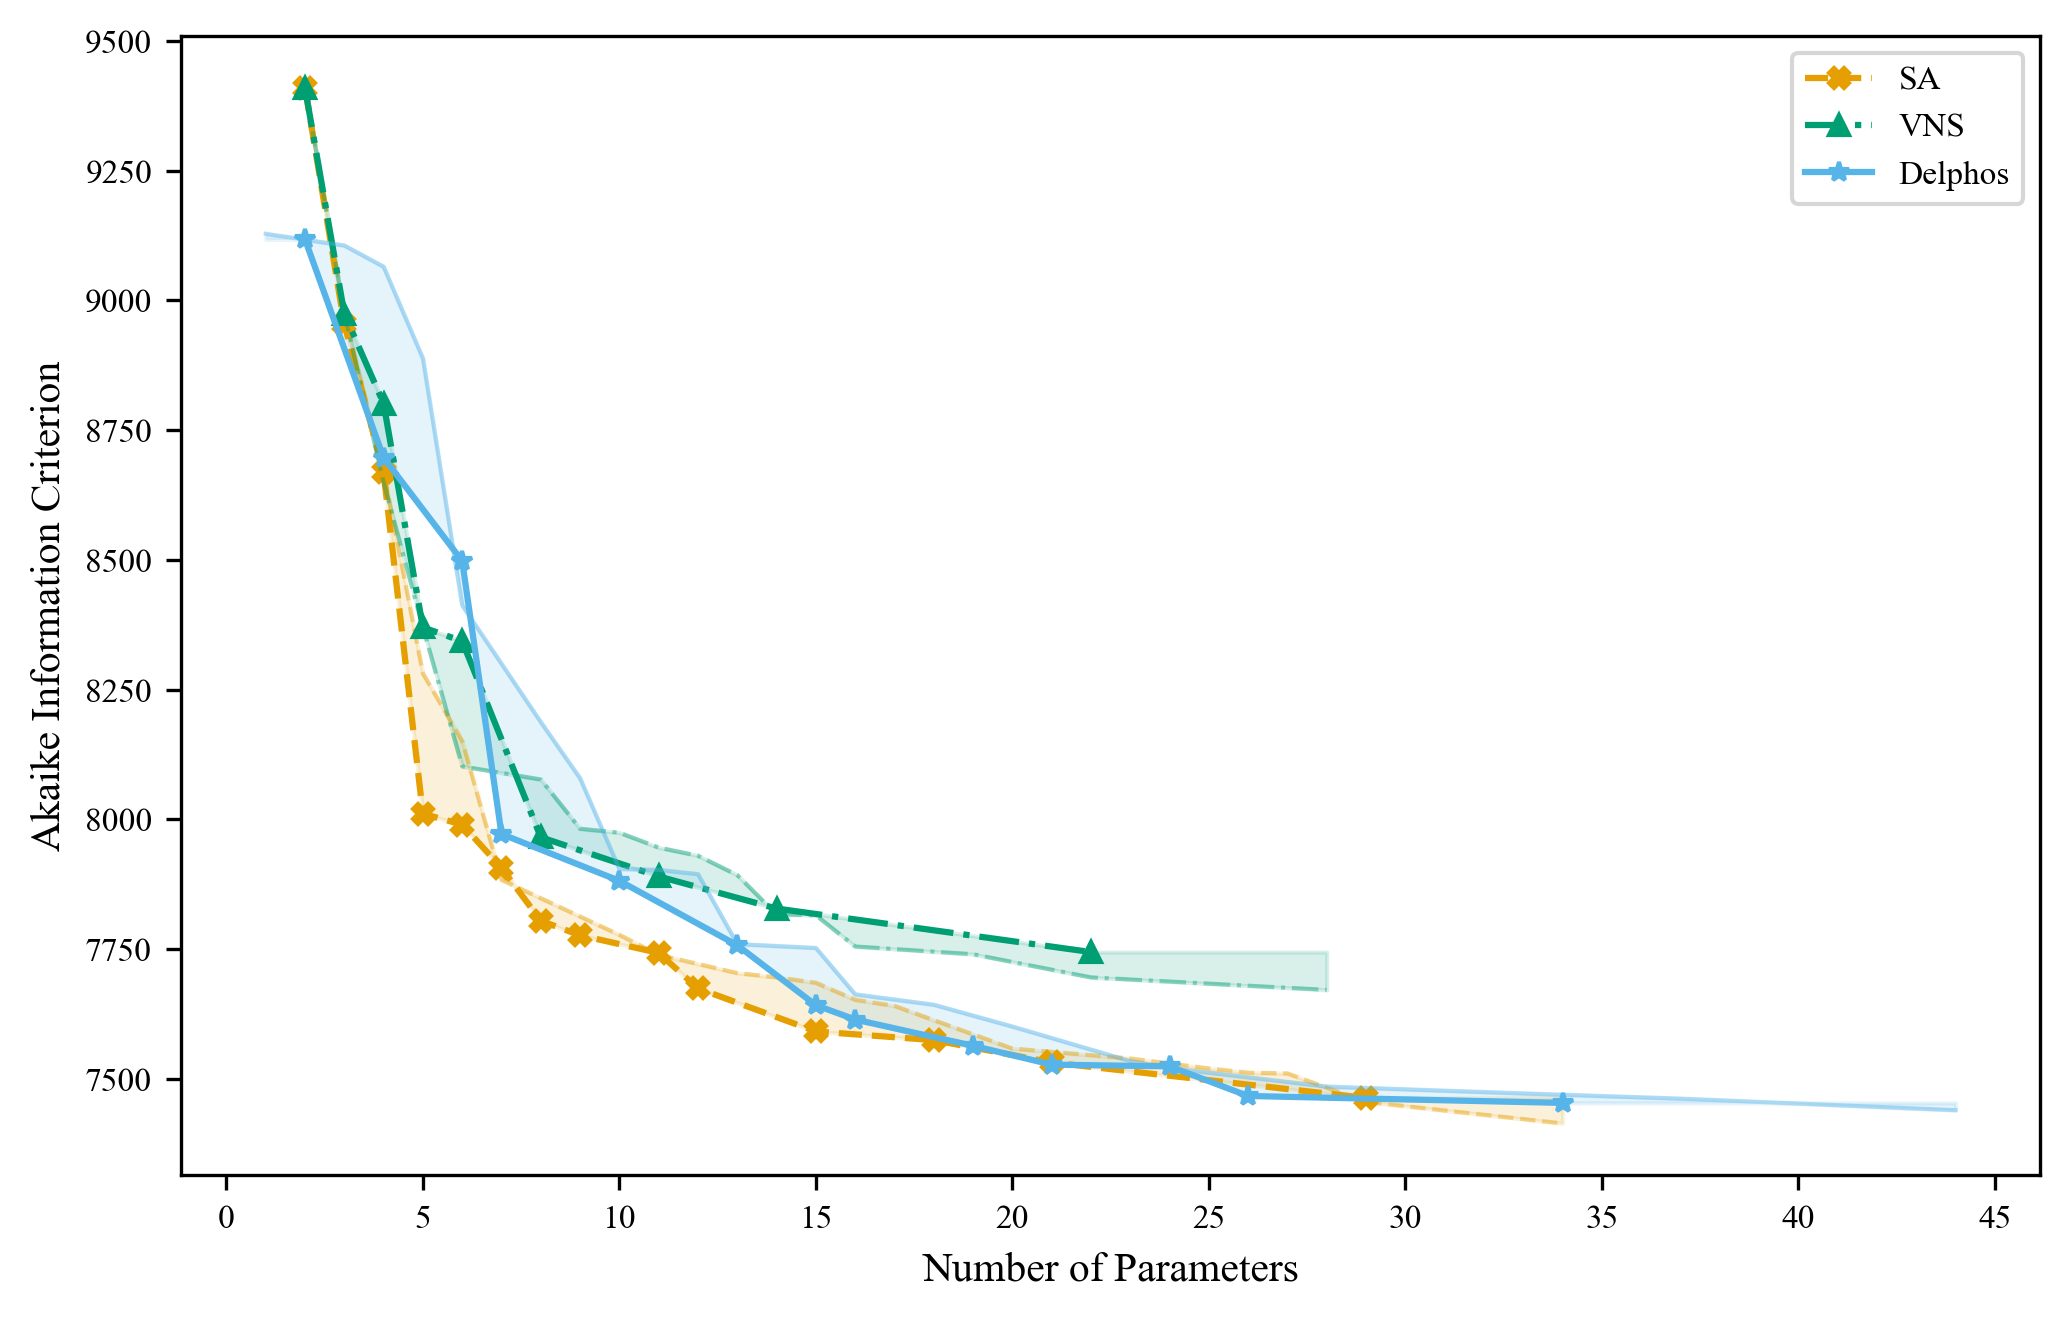

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

base_dir = str(Path.cwd().parent)
methods = ["Delphos", "SA", "VNS"]
seeds = [f"seed_{i}" for i in range(101, 111)]
max_attempt = 1500 
budget = f"B_{max_attempt}"

# --- 1: Collect Data and Extract Strict Pareto Front ---
data_collection = {method: [] for method in methods}

for method in methods:
    for seed in seeds:        
        if method == "Delphos":
            filename = "models_new.csv"
        else:
            filename = "estimations.csv"
            
        file_path = os.path.join(base_dir, method, budget, seed, filename)                 
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue
            
        try:
            if method == "Delphos":
                df = pd.read_csv(file_path, usecols=['numParams', 'AIC'])
                
            elif method == "SA":
                df = pd.read_csv(file_path, usecols=['parameters', 'aic'])
                df['AIC'] = df['aic'] 
                df = df.rename(columns={'parameters': 'numParams'})
                
            elif method == "VNS":
                df = pd.read_csv(file_path, usecols=['log_likelihood', 'parameters'])
                df['AIC'] = 2 * df['parameters'] - 2 * df['log_likelihood']
                df = df.rename(columns={'parameters': 'numParams'})
            
            df = df[['numParams', 'AIC']].dropna()
            
            # --- EXACT PARETO FRONT FILTERING ---
            df_sorted = df.sort_values(by=['numParams', 'AIC'])
            
            pareto_front = []
            min_aic_seen = float('inf')
            
            for _, row in df_sorted.iterrows():
                if row['AIC'] < min_aic_seen:
                    pareto_front.append((row['numParams'], row['AIC']))
                    min_aic_seen = row['AIC']
            
            if pareto_front:
                pf_df = pd.DataFrame(pareto_front, columns=['numParams', 'AIC'])
                pf_series = pf_df.set_index('numParams')['AIC']
                data_collection[method].append(pf_series)
            
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            
print("Data successfully loaded and non-dominated Pareto fronts extracted!")



# ==============================================================================
# 1. SETTINGS 
# ==============================================================================
plt.rcParams.update({
    "font.family": "serif",               
    "font.serif": ["Times New Roman", "Computer Modern Roman", "serif"],
    "font.size": 10,                      # Base font size
    "axes.titlesize": 10,                 
    "axes.labelsize": 10,                 # Axis labels
    "xtick.labelsize": 8,                 # X-axis ticks
    "ytick.labelsize": 8,                 # Y-axis ticks
    "legend.fontsize": 8,                 # Legend font size
    "axes.grid": False,                    # Add a subtle grid
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "axes.spines.top": True,             # Clean look (remove top box line)
    "axes.spines.right": True,           # Clean look (remove right box line)
    "figure.dpi": 300,                    # High resolution 
    "savefig.bbox": "tight",
})

# ==============================================================================
# 2. SEED DISTANCE and CLOSE/FAR MODEL EXTRACTION
# ==============================================================================
def get_model_id(method, seed_name, target_params, target_aic):
    """Helper function to read the CSV and find the 'attempt' ID for a specific model."""
    filename = "models_new.csv" if method == "Delphos" else "estimations.csv"
    file_path = os.path.join(base_dir, method, budget, seed_name, filename)
    
    if method == "Delphos":
        df = pd.read_csv(file_path, usecols=['attempt', 'numParams', 'AIC', 'specification'])
    elif method == "SA":
        df = pd.read_csv(file_path, usecols=['attempt', 'parameters', 'aic'])
        df['AIC'] = df['aic']
        df = df.rename(columns={'parameters': 'numParams'})
    elif method == "VNS":
        df = pd.read_csv(file_path, usecols=['attempt', 'log_likelihood', 'parameters'])
        df['AIC'] = 2 * df['parameters'] - 2 * df['log_likelihood']
        df = df.rename(columns={'parameters': 'numParams'})
        
    df = df.dropna(subset=['numParams', 'AIC'])
    match = df[(df['numParams'] == target_params) &  (np.abs(df['AIC'] - target_aic) < 1e-6)]
    if 'specification' in df.columns:
        print(match['specification'])
    return int(match['attempt'].iloc[0]) if not match.empty else "N/A"

for method, series_list in data_collection.items():
    # 1. Calculate seed distances
    distances = []
    for seed_idx, s in enumerate(series_list):
        p = s.index.values / s.index.values.max()
        a = s.values / s.values.max()
        total_dist = np.sum(np.sqrt(p**2 + a**2))
        distances.append((seed_idx, total_dist))
    
    distances.sort(key=lambda x: x[1])
    closest = distances[0]
    farthest = distances[-1]
    # --- CLOSEST SEED (Best/Min AIC) ---
    closest_series = series_list[closest[0]]
    min_aic_closest = closest_series.min()
    num_params_closest = closest_series.idxmin()
    closest_seed_name = seeds[closest[0]]
    closest_model_id = get_model_id(method, closest_seed_name, num_params_closest, min_aic_closest)
    
    # --- FARTHEST SEED (Worst/Max AIC) ---
    farthest_series = series_list[farthest[0]]
    max_aic_farthest = farthest_series.max()
    num_params_farthest = farthest_series.idxmax()
    farthest_seed_name = seeds[farthest[0]]
    farthest_model_id = get_model_id(method, farthest_seed_name, num_params_farthest, max_aic_farthest)
    
    # --- PRINT RESULTS ---
    print(f"--- {method} ---")
    print(f"Closest: seed {closest[0]} (dist: {closest[1]:.1f})")
    print(f"  -> Min AIC Model - ID (attempt): {closest_model_id}, AIC: {min_aic_closest:.2f}, Params: {num_params_closest}")
    print(f"Farthest: seed {farthest[0]} (dist: {farthest[1]:.1f})")
    print(f"  -> Max AIC Model - ID (attempt): {farthest_model_id}, AIC: {max_aic_farthest:.2f}, Params: {num_params_farthest}\n")

# ==============================================================================
# 3. PLOTTING
# ==============================================================================
COLORS = {'Delphos': '#56B4E9', 'SA': '#E69F00', 'VNS': '#009E73'}
LINE_STYLES = {'Delphos': '-', 'SA': '--', 'VNS': '-.'}
MARKERS = {'Delphos': '*', 'SA': 'X', 'VNS': '^'}

fig, ax = plt.subplots(figsize=(7, 4.5))
for method in ['SA', 'VNS', 'Delphos']:#, 'VNS'
    series_list = data_collection[method]    
    
    dists = []
    for i, s in enumerate(series_list):
        p = s.index.values / s.index.values.max()
        a = s.values / s.values.max()
        dists.append((i, np.sum(np.sqrt(p**2 + a**2))))
    dists.sort(key=lambda x: x[1])
    
    s_min = series_list[dists[0][0]]
    s_max = series_list[dists[-1][0]]
    
    x_common = np.union1d(s_min.index.values, s_max.index.values)
    y_min_interp = np.interp(x_common, s_min.index.values, s_min.values)
    y_max_interp = np.interp(x_common, s_max.index.values, s_max.values)
    
    color = COLORS[method]
    
    ax.fill_between(x_common, y_min_interp, y_max_interp, color=color, alpha=0.15)    
    ax.plot(s_max.index, s_max.values, linestyle=LINE_STYLES[method], color=color, alpha=0.4, linewidth=1)
    ax.plot(s_min.index, s_min.values,linestyle=LINE_STYLES[method], color=color, linewidth=1.5, marker=MARKERS[method], markersize=5, label=f'{method}')

ax.set_xlabel('Number of Parameters')
ax.set_ylabel('Akaike Information Criterion')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend( loc='upper right')
fig.tight_layout()
#plt.savefig(f"swissmetro_pareto_front_AIC_methods.pdf", format='pdf', dpi=300)

plt.show()